# Cellpose 4 (cpsam) + Omnipose — same image, both on Apple Silicon GPU

This notebook runs the modern cellpose `cpsam` model **and** an omnipose model on the same tissue image, both on MPS.

The trick: install the official `cellpose` (4.x) **and** the legacy `cellpose-omni` fork (which provides the omni path) side-by-side. They live in different Python namespaces so they coexist:

| import | what you get |
| --- | --- |
| `from cellpose import models` | cellpose 4.x `cpsam` (SAM-based unified model) |
| `from cellpose_omni import models` | legacy cellpose UNet + `omni=True` flag, all `*_omni` models |

Both pipelines use the GPU on Apple Silicon (`device='mps'`).


## 1. Versions and device

In [1]:
import sys, warnings
from importlib.metadata import version as _v
warnings.filterwarnings("ignore")
import numpy as np, torch
print("python        :", sys.version.split()[0])
print("numpy         :", np.__version__)
print("torch         :", torch.__version__)
print("cellpose      :", _v("cellpose"))
print("cellpose-omni :", _v("cellpose-omni"))
print("omnipose      :", _v("omnipose"))
print("MPS available :", torch.backends.mps.is_available())


python        : 3.11.15
numpy         : 2.4.4
torch         : 2.11.0
cellpose      : 4.1.1
cellpose-omni : 0.9.1
omnipose      : 0.4.4
MPS available : True


## 2. Synthetic test image: four shape classes including a tight colony

A reproducible 384×512 fluorescence-like image with four shape classes:
- **8 round cells** (radius ~16–30 px) — easy case
- **6 elongated rods** (length ~60 px, width ~12 px, aspect ~5)
- **5 super-long-thin filaments** (length ~90 px, width ~7 px, aspect ~12)
- **6 cells in a tightly-packed colony** (length ~60 px, width ~12 px, *touching* — minimal gap between adjacent cells) — this is the canonical regime where cellpose's flow-to-mass-center logic should fail (it merges touching cells) and omnipose's distance-field reconstruction should win

We have ground truth, so we can grade each method per shape class.

image: (384, 512), range [0.00, 1.00], objects: 25


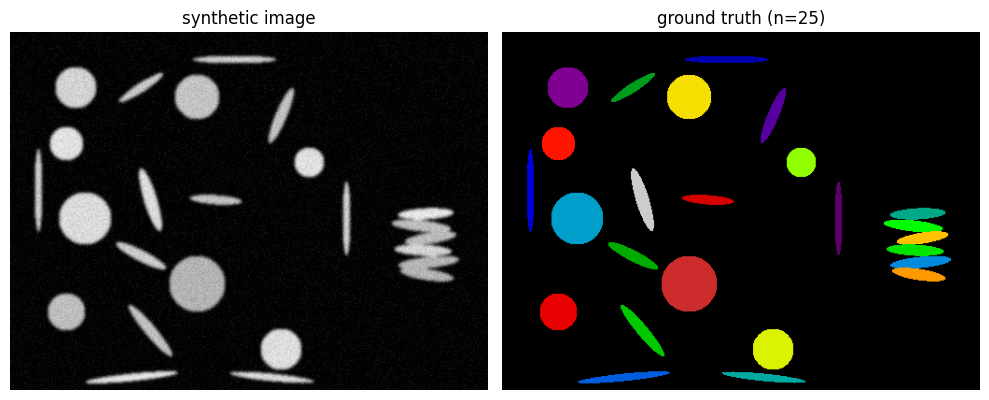

In [2]:
import numpy as np, matplotlib.pyplot as plt
from skimage.draw import disk, ellipse
from skimage.filters import gaussian

rng = np.random.default_rng(7)
H, W = 384, 512
img = np.zeros((H, W), dtype=np.float32)
gt  = np.zeros((H, W), dtype=np.int32)

label = 0
for r, c, rad in [(60,70,22),(120,60,18),(200,80,28),(300,60,20),
                  (70,200,24),(140,320,16),(270,200,30),(340,290,22)]:
    label += 1
    rr, cc = disk((r, c), rad, shape=img.shape)
    img[rr, cc] = 0.7 + 0.2 * rng.random()
    gt[rr, cc]  = label

for r, c, a, b, rot in [(180,150,35,7,0.3),(240,140,30,6,1.1),(90,290,32,6,-0.4),
                        (180,220,28,5,1.5),(320,150,36,6,0.7),(60,140,28,5,-1.0)]:
    label += 1
    rr, cc = ellipse(r, c, a, b, shape=img.shape, rotation=rot)
    img[rr, cc] = 0.7 + 0.2 * rng.random()
    gt[rr, cc]  = label

# super-long-thin filaments (aspect ~12) — placed in image edges/corners to avoid existing cells
for r, c, a, b, rot in [(30, 240, 4, 45, 0.0),     # top, near-horizontal
                        (170, 30, 45, 4, 0.0),     # left edge, vertical
                        (370, 130, 4, 50, 0.1),    # bottom-left, near-horizontal
                        (370, 280, 4, 45, -0.1),   # bottom-mid, near-horizontal
                        (200, 360, 40, 4, 0.0)]:   # right edge of original 384 region, vertical
    label += 1
    rr, cc = ellipse(r, c, a, b, shape=img.shape, rotation=rot)
    img[rr, cc] = 0.7 + 0.2 * rng.random()
    gt[rr, cc]  = label

# tight colony of 6 long cells — packed with minimal gap, varied rotations, in the 128-wide strip cols 384-512
for r, c, a, b, rot in [(195, 445, 6, 30,  0.05),
                        (208, 440, 6, 32, -0.10),
                        (221, 450, 6, 28,  0.15),
                        (234, 442, 6, 31, -0.05),
                        (247, 448, 6, 33,  0.10),
                        (260, 446, 6, 29, -0.15)]:
    label += 1
    rr, cc = ellipse(r, c, a, b, shape=img.shape, rotation=rot)
    img[rr, cc] = 0.7 + 0.2 * rng.random()
    gt[rr, cc]  = label

img = gaussian(img, sigma=1.5)
img = np.clip(img + 0.04 * rng.standard_normal(img.shape).astype(np.float32), 0, 1)

print(f"image: {img.shape}, range [{img.min():.2f}, {img.max():.2f}], objects: {label}")

# Helper: shuffle integer labels so spatially-adjacent cells get visually-distinct colors
def shuffle_labels(masks, seed=0):
    n = int(masks.max())
    if n == 0:
        return masks
    perm = np.concatenate([[0], np.random.default_rng(seed).permutation(np.arange(1, n + 1))])
    return perm[masks]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img, cmap="gray"); ax[0].set_title("synthetic image"); ax[0].axis("off")
ax[1].imshow(shuffle_labels(gt, seed=1), cmap="nipy_spectral"); ax[1].set_title(f"ground truth (n={label})"); ax[1].axis("off")
plt.tight_layout(); plt.show()


## 3. Cellpose 4 — `cpsam`

Official cellpose 4.x. The cpsam model is a SAM-based unified segmenter — no `diameter` needed (it's estimated). Weights auto-download (~150 MB) on first use.

In [3]:
import time
from cellpose import models as cp_modern

m_sam = cp_modern.CellposeModel(gpu=True, pretrained_model="cpsam")
print("cpsam loaded on:", m_sam.device)

t0 = time.time()
masks_sam, flows_sam, styles_sam = m_sam.eval(img, diameter=None, niter=200)
print(f"cpsam eval: n={int(masks_sam.max())} objects in {time.time()-t0:.2f}s on {m_sam.device}")


cpsam loaded on: mps


cpsam eval: n=25 objects in 1.00s on mps


## 4. Omnipose — `cyto2_omni` via the cellpose-omni fork

The `omni=True` flag swaps cellpose's standard mask-from-flow logic for the omnipose distance-field + Eulerian-flow recovery — better at clumped or elongated objects.

In [4]:
from cellpose_omni import models as cp_legacy

m_omni = cp_legacy.CellposeModel(
    gpu=True, model_type="cyto2_omni", omni=True, net_avg=False
)
print("cyto2_omni loaded on:", m_omni.device)

t0 = time.time()
masks_omni, flows_omni, styles_omni = m_omni.eval(
    img, channels=[0, 0], diameter=40, omni=True,
)
print(f"cyto2_omni eval: n={int(masks_omni.max())} objects in {time.time()-t0:.2f}s on {m_omni.device}")


2026-05-05 13:36:31,843 [INFO] >>cyto2_omni<< model set to be used


2026-05-05 13:36:31,848 [INFO] ** TORCH GPU version installed and working. **


2026-05-05 13:36:31,848 [INFO] >>>> using GPU


cyto2_omni loaded on: mps


True flow error 0.7602296 0.12309227636539585
cyto2_omni eval: n=19 objects in 0.59s on mps


## 5. Side-by-side comparison

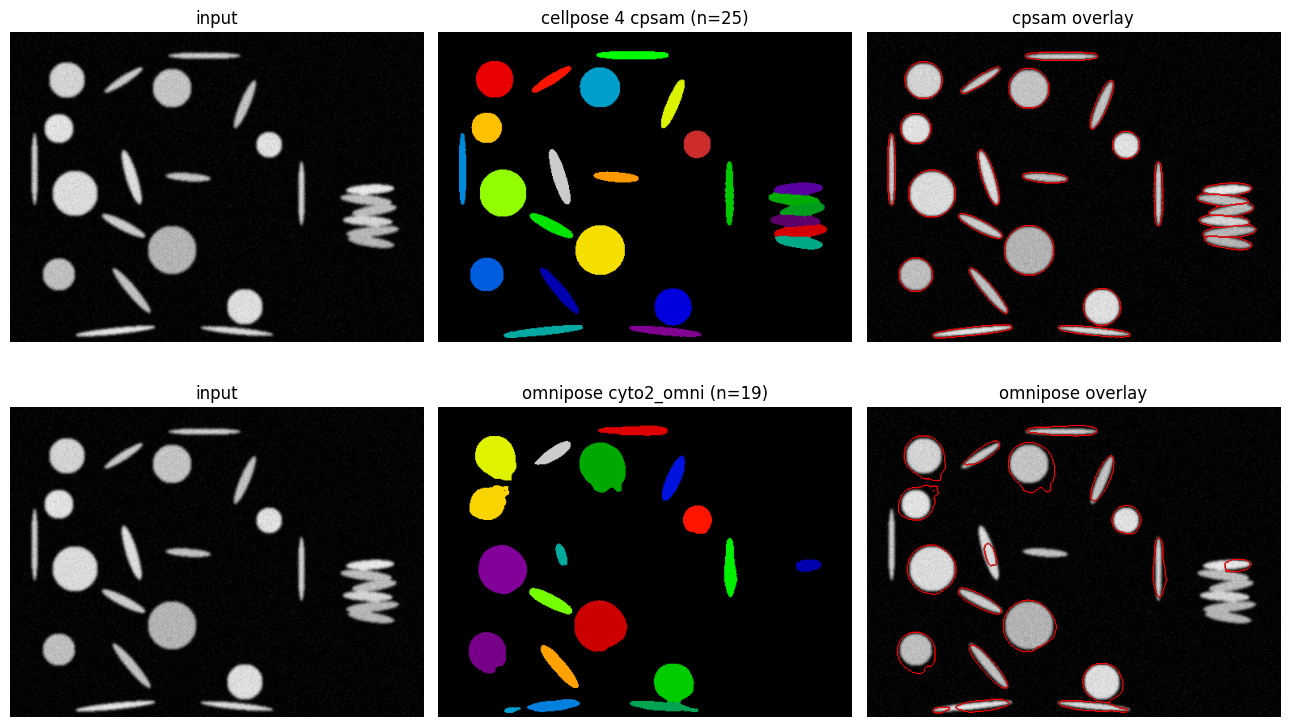

In [5]:
from skimage.segmentation import find_boundaries

fig, ax = plt.subplots(2, 3, figsize=(13, 8))
ax[0, 0].imshow(img, cmap="gray"); ax[0, 0].set_title("input"); ax[0, 0].axis("off")
ax[0, 1].imshow(shuffle_labels(masks_sam, seed=2), cmap="nipy_spectral")
ax[0, 1].set_title(f"cellpose 4 cpsam (n={int(masks_sam.max())})"); ax[0, 1].axis("off")
b = find_boundaries(masks_sam)
ax[0, 2].imshow(img, cmap="gray")
ax[0, 2].imshow(np.ma.masked_where(~b, b), cmap="autumn")
ax[0, 2].set_title("cpsam overlay"); ax[0, 2].axis("off")

ax[1, 0].imshow(img, cmap="gray"); ax[1, 0].set_title("input"); ax[1, 0].axis("off")
ax[1, 1].imshow(shuffle_labels(masks_omni, seed=3), cmap="nipy_spectral")
ax[1, 1].set_title(f"omnipose cyto2_omni (n={int(masks_omni.max())})"); ax[1, 1].axis("off")
b = find_boundaries(masks_omni)
ax[1, 2].imshow(img, cmap="gray")
ax[1, 2].imshow(np.ma.masked_where(~b, b), cmap="autumn")
ax[1, 2].set_title("omnipose overlay"); ax[1, 2].axis("off")
plt.tight_layout(); plt.show()


## 6. Score each method against ground truth

Per-object IoU after a Hungarian match between predicted and ground-truth labels. This tells us how cleanly each method recovered each cell — and lets us see if omnipose handles the elongated rods better than cpsam (the historical reason to use omnipose).

In [6]:
from scipy.optimize import linear_sum_assignment

def score(pred, truth):
    """Return list of best per-truth-object IoUs (0 if missed)."""
    tlabs = [l for l in np.unique(truth) if l != 0]
    plabs = [l for l in np.unique(pred)  if l != 0]
    if not plabs:
        return [0.0] * len(tlabs)
    iou = np.zeros((len(tlabs), len(plabs)))
    for i, T in enumerate(tlabs):
        tmask = truth == T
        for j, P in enumerate(plabs):
            pmask = pred == P
            inter = np.logical_and(tmask, pmask).sum()
            union = np.logical_or(tmask, pmask).sum()
            iou[i, j] = inter / union if union else 0.0
    ri, ci = linear_sum_assignment(-iou)
    matched = {i: iou[i, j] for i, j in zip(ri, ci)}
    return [matched.get(i, 0.0) for i in range(len(tlabs))]

n_round, n_elong, n_thin, n_colony = 8, 6, 5, 6
i = 0
sl_round  = slice(i, i + n_round);  i += n_round
sl_elong  = slice(i, i + n_elong);  i += n_elong
sl_thin   = slice(i, i + n_thin);   i += n_thin
sl_colony = slice(i, i + n_colony)

ious_sam  = score(masks_sam,  gt)
ious_omni = score(masks_omni, gt)

def fmt(x): return [f"{v:.2f}" for v in x]
print(f"                          round ({n_round})                       elongated ({n_elong})              super-thin ({n_thin})           colony ({n_colony})")
print("cpsam      per-cell IoU :", fmt(ious_sam[sl_round]),  fmt(ious_sam[sl_elong]),  fmt(ious_sam[sl_thin]),  fmt(ious_sam[sl_colony]))
print("cyto2_omni per-cell IoU :", fmt(ious_omni[sl_round]), fmt(ious_omni[sl_elong]), fmt(ious_omni[sl_thin]), fmt(ious_omni[sl_colony]))
print()
def m(x, sl): return np.mean(x[sl]) if len(x[sl]) else float("nan")
print(f"cpsam      mean IoU: round={m(ious_sam, sl_round):.2f}  elongated={m(ious_sam, sl_elong):.2f}  super-thin={m(ious_sam, sl_thin):.2f}  colony={m(ious_sam, sl_colony):.2f}")
print(f"cyto2_omni mean IoU: round={m(ious_omni, sl_round):.2f}  elongated={m(ious_omni, sl_elong):.2f}  super-thin={m(ious_omni, sl_thin):.2f}  colony={m(ious_omni, sl_colony):.2f}")


                          round (8)                       elongated (6)              super-thin (5)           colony (6)
cpsam      per-cell IoU : ['0.91', '0.89', '0.92', '0.91', '0.92', '0.87', '0.94', '0.91'] ['0.83', '0.82', '0.77', '0.78', '0.83', '0.79'] ['0.68', '0.78', '0.74', '0.73', '0.69'] ['0.77', '0.78', '0.77', '0.79', '0.80', '0.79']
cyto2_omni per-cell IoU : ['0.70', '0.63', '0.87', '0.68', '0.65', '0.79', '0.89', '0.81'] ['0.36', '0.72', '0.68', '0.00', '0.71', '0.60'] ['0.59', '0.00', '0.50', '0.67', '0.54'] ['0.44', '0.00', '0.00', '0.00', '0.00', '0.00']

cpsam      mean IoU: round=0.91  elongated=0.80  super-thin=0.73  colony=0.78
cyto2_omni mean IoU: round=0.75  elongated=0.51  super-thin=0.46  colony=0.07


## 7. Flow vector fields and prediction maps

Before either model produces a mask, the network outputs (a) flow vectors that point each pixel toward the cell it belongs to, and (b) a scalar 'is this a cell pixel?' field. Visualizing these helps explain *why* the final masks look the way they do — and where the model is uncertain.

A subtle but important difference: cpsam's scalar field is **cell probability** (log-odds, can be negative), while cyto2_omni's scalar is the **omnipose distance field** — the predicted Euclidean distance from each pixel to its cell's boundary, peaking along the medial axis. The distance field is omnipose's signature design: it gives well-defined gradients even for elongated cells without a single 'center'.


In [7]:
# Flow tuple layout (both methods):
#   flows[0]: (H, W, 3) HSV-colored flow direction (uint8) — direction = hue, magnitude = saturation
#   flows[1]: (2, H, W) flow vectors (dY, dX), float32
#   flows[2]: (H, W) scalar — cellprob (cpsam) or distance field (cyto2_omni omni=True)

flow_color_sam,  flow_vec_sam,  cellprob_sam  = flows_sam[0],  flows_sam[1],  flows_sam[2]
flow_color_omni, flow_vec_omni, dist_omni     = flows_omni[0], flows_omni[1], flows_omni[2]

print("cpsam      cellprob range:", round(float(cellprob_sam.min()), 2), "to", round(float(cellprob_sam.max()), 2))
print("cyto2_omni distance range:", round(float(dist_omni.min()), 2),    "to", round(float(dist_omni.max()), 2))


cpsam      cellprob range: -10.12 to 8.5
cyto2_omni distance range: -5.52 to 18.09


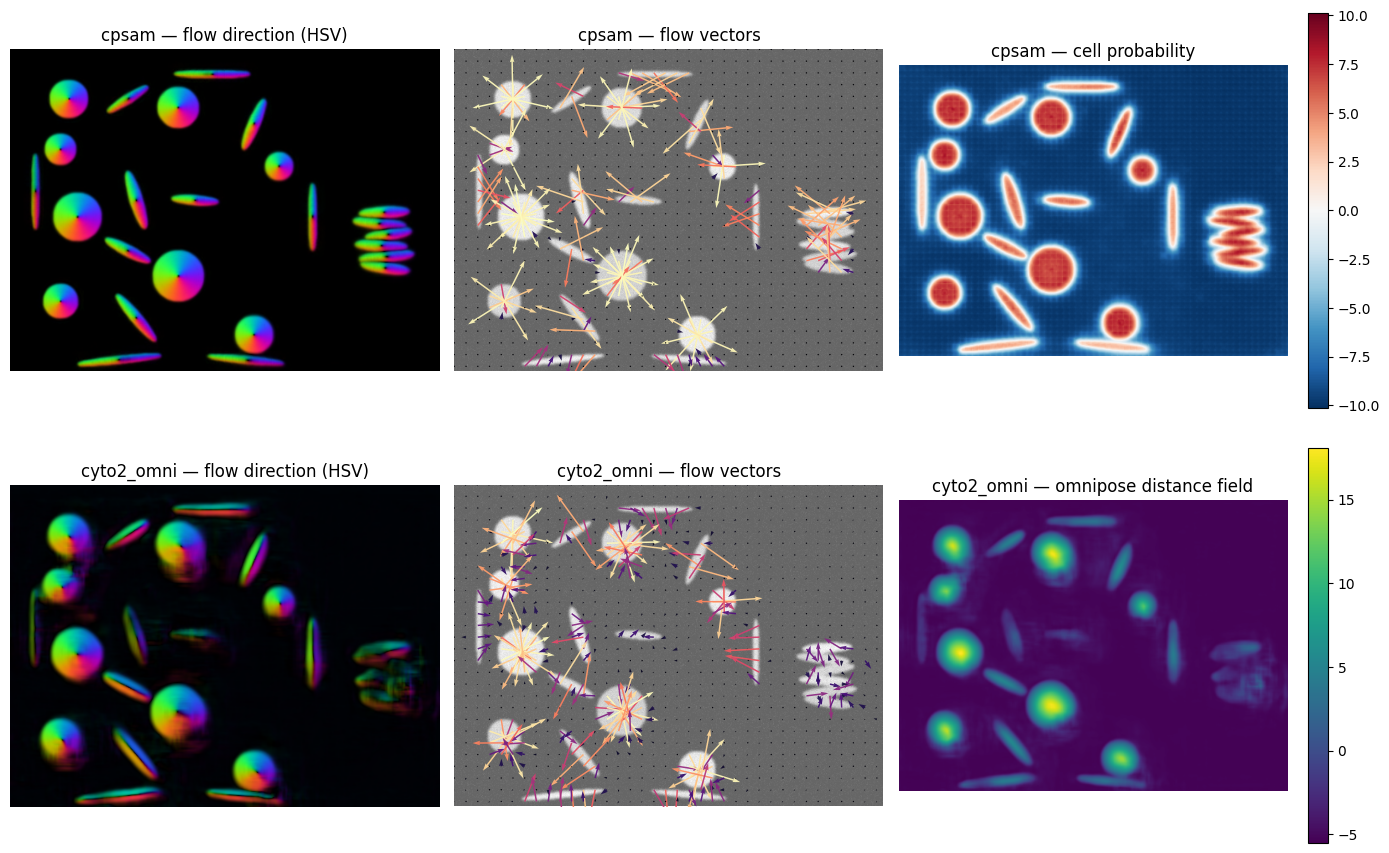

In [8]:
# Helper: subsampled quiver overlay
def quiver_overlay(ax, base_img, flow_vec, step=14, color_by_mag=True, scale=40):
    H, W = base_img.shape
    yy, xx = np.mgrid[0:H:step, 0:W:step]
    vy = flow_vec[0, ::step, ::step]
    vx = flow_vec[1, ::step, ::step]
    mag = np.sqrt(vy**2 + vx**2)
    ax.imshow(base_img, cmap="gray", alpha=0.6)
    if color_by_mag:
        ax.quiver(xx, yy, vx, -vy, mag, cmap="magma", scale=scale, width=0.0035, alpha=0.95)
    else:
        ax.quiver(xx, yy, vx, -vy, scale=scale, width=0.0035, color="C1", alpha=0.95)
    ax.set_xlim(0, W); ax.set_ylim(H, 0)

fig, ax = plt.subplots(2, 3, figsize=(14, 9))

ax[0, 0].imshow(flow_color_sam); ax[0, 0].set_title("cpsam — flow direction (HSV)"); ax[0, 0].axis("off")
quiver_overlay(ax[0, 1], img, flow_vec_sam); ax[0, 1].set_title("cpsam — flow vectors"); ax[0, 1].axis("off")
im0 = ax[0, 2].imshow(cellprob_sam, cmap="RdBu_r", vmin=-abs(cellprob_sam).max(), vmax=abs(cellprob_sam).max())
ax[0, 2].set_title("cpsam — cell probability"); ax[0, 2].axis("off"); fig.colorbar(im0, ax=ax[0, 2], fraction=0.046)

ax[1, 0].imshow(flow_color_omni); ax[1, 0].set_title("cyto2_omni — flow direction (HSV)"); ax[1, 0].axis("off")
quiver_overlay(ax[1, 1], img, flow_vec_omni); ax[1, 1].set_title("cyto2_omni — flow vectors"); ax[1, 1].axis("off")
im1 = ax[1, 2].imshow(dist_omni, cmap="viridis"); ax[1, 2].set_title("cyto2_omni — omnipose distance field"); ax[1, 2].axis("off")
fig.colorbar(im1, ax=ax[1, 2], fraction=0.046)

plt.tight_layout(); plt.show()


## 8. Omnipose-specific diagnostics

Beyond flow vectors, omnipose's `eval()` exposes additional output channels that aren't in the standard cellpose pipeline. The most useful for understanding *how* a cell got called:

1. **Distance field** (already shown above) — peaks along each cell's medial axis. Used both as the 'cellness' indicator and as the potential function whose gradient gives the flow.
2. **Boundary prediction** — explicit per-pixel boundary score. Cellpose has no equivalent; this is what helps omnipose separate touching cells.
3. **Pixel trajectories after dynamics** (`flows[3]`) — for each pixel, the position it converged to after iteratively following the flow. Pixels that converge to the same point form a single cell; visualizing this reveals the model's clustering decisions directly.


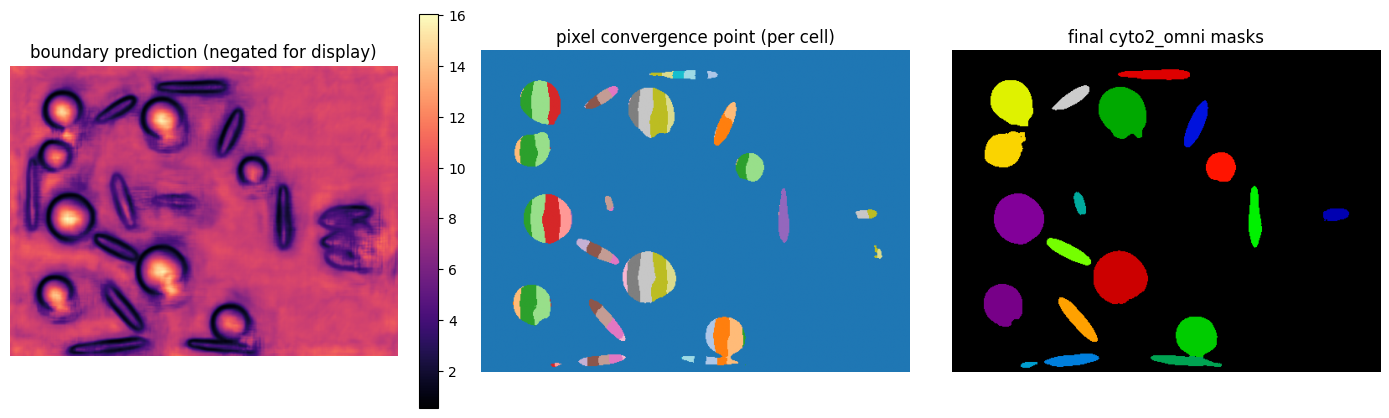

In [9]:
# Boundary field: omnipose's explicit boundary prediction (cyto2_omni flows[4])
boundary_omni = flows_omni[4] if len(flows_omni) > 4 and flows_omni[4] is not None else None

# Final pixel positions after dynamics: flows_omni[3] has shape (2, H+2, W+2)
final_p = flows_omni[3]
# Color each pixel by the (rounded) location it converged to
H_, W_ = img.shape
py = np.clip(final_p[0, :H_, :W_], 0, H_-1).astype(np.int32)
px = np.clip(final_p[1, :H_, :W_], 0, W_-1).astype(np.int32)
# 2D hash for per-convergence-point coloring
trace_id = (py.astype(np.int64) * W_ + px.astype(np.int64))

fig, ax = plt.subplots(1, 3, figsize=(14, 4.5))
if boundary_omni is not None:
    im = ax[0].imshow(-boundary_omni, cmap="magma")
    ax[0].set_title("boundary prediction (negated for display)")
    fig.colorbar(im, ax=ax[0], fraction=0.046)
else:
    ax[0].text(0.5, 0.5, "boundary not in flows", ha="center"); ax[0].set_title("boundary")
ax[0].axis("off")

# Mask the trace map to only show in-cell pixels (use distance>0 as proxy)
trace_show = np.where(dist_omni > 0, trace_id % 256, 0)
ax[1].imshow(trace_show, cmap="tab20"); ax[1].set_title("pixel convergence point (per cell)"); ax[1].axis("off")

ax[2].imshow(shuffle_labels(masks_omni, seed=3), cmap="nipy_spectral"); ax[2].set_title("final cyto2_omni masks"); ax[2].axis("off")
plt.tight_layout(); plt.show()


**How to read these:**

- **Boundary field** — bright = high boundary score. Where two cells touch, you'll see a bright line; this is what allows omnipose to split clumps that cellpose merges.
- **Pixel convergence map** — each pixel is colored by where it ended up after iteratively following the flow. Connected regions of the same color = one cell. This is the *raw clustering decision* before any size-filter or smoothing — useful for spotting cases where one cell got fragmented or two cells got merged.
- **Distance field vs cellprob** — if a pixel has high distance value but the corresponding cellprob from cpsam is low (or vice versa), the two methods disagree about whether that pixel belongs to a cell. Overlaying both is a quick way to find tricky regions.

If you're debugging a specific cell that one method called and the other missed, look up its location in the flow vector image first (which way are pixels flowing?) and the boundary field (is the model 'seeing' a boundary that splits the cell, or merging two cells that should be split?).


## 9. Summary

End-to-end working stack with **both** segmentation paths on the **same** Apple Silicon GPU:

```python
from cellpose      import models as cp_modern   # cellpose 4 (cpsam)
from cellpose_omni import models as cp_legacy   # legacy fork w/ omni

m_sam  = cp_modern.CellposeModel(gpu=True, pretrained_model="cpsam")
m_omni = cp_legacy.CellposeModel(gpu=True, model_type="cyto2_omni", omni=True, net_avg=False)

masks_sam,  *_ = m_sam.eval(  img, diameter=None)
masks_omni, *_ = m_omni.eval( img, channels=[0,0], diameter=30, omni=True)
```

**API differences to keep straight:**
- cpsam: no `channels`, no `omni`, `diameter=None` lets the model estimate
- cyto2_omni (legacy fork): needs `channels=[c1,c2]` and `omni=True`, give a rough `diameter`

**Other omni models in the legacy fork** (drop-in for `cyto2_omni`): `bact_phase_omni`, `bact_fluor_omni`, `plant_omni`, `worm_omni`, `worm_high_res_omni`, `worm_bact_omni`.

**Other modern cellpose models**: only `cpsam` ships in 4.x.

**On this image:** see Section 6 for per-class IoU numbers across the four shape classes. The two diagnostic classes for omnipose's design intent are (1) super-long-thin filaments (aspect ~12) and (2) the tightly-packed colony of touching long cells. The colony in particular is the regime where cellpose's flow-to-mass-center logic should fail and omnipose's distance-field reconstruction should win. Watch for the colony IoU column.
